Refactored

In [53]:
import pandas as pd
import pandas_ta as ta
from tqdm import tqdm
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
from backtesting import Strategy
from backtesting import Backtest
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

tqdm.pandas()
ema_length = 60

tradingData = pd.read_csv("../data/^ixic-1d-1y.csv")
tradingData.Date = pd.to_datetime(tradingData.Date, utc=True)
tradingData=tradingData[tradingData.High != tradingData.Low]
tradingData.set_index('Date', inplace=True)
tradingData.drop(['Dividends', 'Stock Splits', 'Volume'], axis=1, inplace=True)
tradingData

,Open,High,Low,Close
Date,,,,
2023-04-20 04:00:00+00:00,12039.080078,12155.959961,12011.950195,12059.559570
2023-04-21 04:00:00+00:00,12046.030273,12097.150391,11986.820312,12072.459961
2023-04-24 04:00:00+00:00,12053.469727,12103.580078,11960.299805,12037.200195
2023-04-25 04:00:00+00:00,11968.809570,11990.459961,11798.769531,11799.160156
2023-04-26 04:00:00+00:00,11913.230469,11967.990234,11833.070312,11854.349609
...,...,...,...,...
2024-04-15 04:00:00+00:00,16276.469727,16295.269531,15863.879883,15885.019531
2024-04-16 04:00:00+00:00,15856.379883,15965.790039,15822.019531,15865.250000
2024-04-17 04:00:00+00:00,15942.290039,15957.030273,15654.509766,15683.370117


In [54]:
tradingData['EMA'] = ta.ema(tradingData.Close, length=ema_length)
macd = ta.macd(tradingData.Close)
macd

tradingData['MACD'] = macd.loc[:, 'MACD_12_26_9']
tradingData['MACD_signal'] = macd.loc[:, 'MACDs_12_26_9']
tradingData['MACD_histogram'] = macd.loc[:, 'MACDh_12_26_9']
tradingData['ATR'] = ta.atr(tradingData.High, tradingData.Low, tradingData.Close, length=7)
tradingData

,Open,High,Low,Close,EMA,MACD,MACD_signal,MACD_histogram,ATR
Date,,,,,,,,,
2023-04-20 04:00:00+00:00,12039.080078,12155.959961,12011.950195,12059.559570,NaN,NaN,NaN,NaN,NaN
2023-04-21 04:00:00+00:00,12046.030273,12097.150391,11986.820312,12072.459961,NaN,NaN,NaN,NaN,NaN
2023-04-24 04:00:00+00:00,12053.469727,12103.580078,11960.299805,12037.200195,NaN,NaN,NaN,NaN,NaN
2023-04-25 04:00:00+00:00,11968.809570,11990.459961,11798.769531,11799.160156,NaN,NaN,NaN,NaN,NaN
2023-04-26 04:00:00+00:00,11913.230469,11967.990234,11833.070312,11854.349609,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2024-04-15 04:00:00+00:00,16276.469727,16295.269531,15863.879883,15885.019531,15873.865796,26.045661,74.811841,-48.766180,262.987493
2024-04-16 04:00:00+00:00,15856.379883,15965.790039,15822.019531,15865.250000,15873.583311,-2.953963,59.258680,-62.212643,245.956495
2024-04-17 04:00:00+00:00,15942.290039,15957.030273,15654.509766,15683.370117,15867.346813,-40.149740,39.376996,-79.526736,254.037068


In [55]:
def ema_signal(df, current, go_back_number):
  df_slice = df.copy()
  start = max(0, current - go_back_number)
  end = current
  relevant_rows = df_slice.iloc[start:end]

  if all(relevant_rows['High'] < relevant_rows['EMA']):
    return -1
  elif all(relevant_rows['Low'] > relevant_rows['EMA']):
    return 1
  else:
    return 0

tradingData.reset_index(inplace=True)
tradingData['EMA_signal'] = tradingData.progress_apply(
  lambda row: ema_signal(tradingData, row.name, 5), axis='columns')
tradingData

100%|██████████| 252/252 [00:00<00:00, 6820.80it/s]


,Date,Open,High,Low,Close,EMA,MACD,MACD_signal,MACD_histogram,ATR,EMA_signal
0,2023-04-20 04:00:00+00:00,12039.080078,12155.959961,12011.950195,12059.559570,NaN,NaN,NaN,NaN,NaN,-1
1,2023-04-21 04:00:00+00:00,12046.030273,12097.150391,11986.820312,12072.459961,NaN,NaN,NaN,NaN,NaN,0
2,2023-04-24 04:00:00+00:00,12053.469727,12103.580078,11960.299805,12037.200195,NaN,NaN,NaN,NaN,NaN,0
3,2023-04-25 04:00:00+00:00,11968.809570,11990.459961,11798.769531,11799.160156,NaN,NaN,NaN,NaN,NaN,0
4,2023-04-26 04:00:00+00:00,11913.230469,11967.990234,11833.070312,11854.349609,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
247,2024-04-15 04:00:00+00:00,16276.469727,16295.269531,15863.879883,15885.019531,15873.865796,26.045661,74.811841,-48.766180,262.987493,1
248,2024-04-16 04:00:00+00:00,15856.379883,15965.790039,15822.019531,15865.250000,15873.583311,-2.953963,59.258680,-62.212643,245.956495,0
249,2024-04-17 04:00:00+00:00,15942.290039,15957.030273,15654.509766,15683.370117,15867.346813,-40.149740,39.376996,-79.526736,254.037068,0
250,2024-04-18 04:00:00+00:00,15705.690430,15786.120117,15587.500000,15601.500000,15858.630524,-75.365133,16.428570,-91.793703,246.120361,0


In [56]:
def macd_signal(data, current):
    if (
        all(data.loc[current - 3:current - 2, 'MACD'] < data.loc[current - 3:current - 2, 'MACD_signal']) and
        all(data.loc[current - 1:current, 'MACD'] >
            data.loc[current - 1:current, 'MACD_signal'])
    ):
        return 1
    if (
        all(data.loc[current - 3:current - 2, 'MACD'] > data.loc[current - 3:current - 2, 'MACD_signal']) and
        all(data.loc[current - 1:current, 'MACD'] <
            data.loc[current - 1:current, 'MACD_signal'])
    ):
        return -1
    return 0

In [57]:
def total_signal(df, current, go_back_number):
    if (
        all(df.loc[current - go_back_number: current, 'EMA_signal'] == 1) and
        all(df.loc[current - 3:current - 2, 'MACD'] < df.loc[current - 3:current - 2, 'MACD_signal']) and
        all(df.loc[current - 1:current, 'MACD'] > df.loc[current - 1:current, 'MACD_signal'])
        ):
            return 1
    if (
        all(df.loc[current - go_back_number: current, 'EMA_signal'] == -1) and
        all(df.loc[current - 3:current - 2, 'MACD'] > df.loc[current - 3:current - 2, 'MACD_signal']) and
        all(df.loc[current - 1:current, 'MACD'] < df.loc[current - 1:current, 'MACD_signal'])
        ):

            return -1
    return 0

tradingData['TotalSignal'] = tradingData.progress_apply(
       lambda row: total_signal(tradingData, row.name, 7), axis='columns')
tradingData

100%|██████████| 252/252 [00:00<00:00, 5239.74it/s]


,Date,Open,High,Low,Close,EMA,MACD,MACD_signal,MACD_histogram,ATR,EMA_signal,TotalSignal
0,2023-04-20 04:00:00+00:00,12039.080078,12155.959961,12011.950195,12059.559570,NaN,NaN,NaN,NaN,NaN,-1,0
1,2023-04-21 04:00:00+00:00,12046.030273,12097.150391,11986.820312,12072.459961,NaN,NaN,NaN,NaN,NaN,0,0
2,2023-04-24 04:00:00+00:00,12053.469727,12103.580078,11960.299805,12037.200195,NaN,NaN,NaN,NaN,NaN,0,0
3,2023-04-25 04:00:00+00:00,11968.809570,11990.459961,11798.769531,11799.160156,NaN,NaN,NaN,NaN,NaN,0,0
4,2023-04-26 04:00:00+00:00,11913.230469,11967.990234,11833.070312,11854.349609,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
247,2024-04-15 04:00:00+00:00,16276.469727,16295.269531,15863.879883,15885.019531,15873.865796,26.045661,74.811841,-48.766180,262.987493,1,0
248,2024-04-16 04:00:00+00:00,15856.379883,15965.790039,15822.019531,15865.250000,15873.583311,-2.953963,59.258680,-62.212643,245.956495,0,0
249,2024-04-17 04:00:00+00:00,15942.290039,15957.030273,15654.509766,15683.370117,15867.346813,-40.149740,39.376996,-79.526736,254.037068,0,0
250,2024-04-18 04:00:00+00:00,15705.690430,15786.120117,15587.500000,15601.500000,15858.630524,-75.365133,16.428570,-91.793703,246.120361,0,0


In [58]:
print(tradingData[tradingData.TotalSignal != 0].count())
tradingData[tradingData.TotalSignal != 0]

Date              16
Open              16
High              16
Low               16
Close             16
EMA               15
MACD              16
MACD_signal       16
MACD_histogram    16
ATR               16
EMA_signal        16
TotalSignal       16
dtype: int64


,Date,Open,High,Low,Close,EMA,MACD,MACD_signal,MACD_histogram,ATR,EMA_signal,TotalSignal
44,2023-06-23 04:00:00+00:00,13484.099609,13572.190430,13442.650391,13492.519531,NaN,300.262583,323.083067,-22.820484,187.406776,0,-1
59,2023-07-17 04:00:00+00:00,14149.919922,14274.410156,14138.009766,14244.950195,12992.751709,251.186669,231.634462,19.552208,167.171889,0,1
64,2023-07-24 04:00:00+00:00,14081.629883,14110.150391,13997.129883,14058.870117,13173.076832,229.710425,245.914673,-16.204249,175.923975,1,-1
91,2023-08-30 04:00:00+00:00,13961.769531,14050.820312,13924.200195,14019.309570,13528.142541,-20.101550,-63.556747,43.455196,210.201092,0,1
103,2023-09-18 04:00:00+00:00,13669.959961,13751.280273,13663.459961,13710.240234,13634.319092,3.573438,12.997109,-9.423671,164.734383,1,-1
118,2023-10-09 04:00:00+00:00,13326.219727,13509.299805,13277.480469,13484.240234,13493.277596,-110.006397,-135.981451,25.975054,225.193178,-1,1
128,2023-10-23 04:00:00+00:00,12930.849609,13143.219727,12848.830078,13018.330078,13455.714820,-94.603131,-64.053021,-30.550111,232.700141,0,-1
137,2023-11-03 04:00:00+00:00,13362.849609,13520.280273,13344.730469,13478.280273,13332.142780,-89.361058,-135.794933,46.433875,223.149648,-1,1
158,2023-12-05 05:00:00+00:00,14126.400391,14285.660156,14121.759766,14229.910156,13715.733144,216.611894,229.520935,-12.909041,164.828141,1,-1
165,2023-12-14 05:00:00+00:00,14798.719727,14855.620117,14642.230469,14761.559570,13877.297749,242.656052,220.324988,22.331064,175.829538,1,1


In [59]:
def pointpos(x):
    if x['TotalSignal'] == 1:
        return x['Low']-1e-3
    elif x['TotalSignal'] == -1:
        return x['High']+1e-3
    else:
        return np.nan

tradingData['pointpos'] = tradingData.apply(lambda row: pointpos(row), axis='columns')

In [60]:
fig = go.Figure(data=[go.Candlestick(x=tradingData.index,
                open=tradingData['Open'],
                high=tradingData['High'],
                low=tradingData['Low'],
                close=tradingData['Close'])])

fig.add_scatter(x=tradingData.index, y=tradingData['pointpos'], mode="markers",
                marker=dict(size=5, color="MediumPurple"),
                name="entry")

# fig.show(renderer="browser")
fig.show()

In [61]:
class MyStrat(Strategy):
    mysize = 3
    slcoef = 1.1
    TPSLRatio = 1.5
    #rsi_length = 16

    def init(self):
        super().init()
        self.signal1 = self.I(lambda: tradingData.TotalSignal)
        #df['RSI']=ta.rsi(df.Close, length=self.rsi_length)

    def next(self):
        super().next()
        slatr = self.slcoef * self.data.ATR[-1]
        TPSLRatio = self.TPSLRatio

        # if len(self.trades)>0:
        #     if self.trades[-1].is_long and self.data.RSI[-1]>=90:
        #         self.trades[-1].close()
        #     elif self.trades[-1].is_short and self.data.RSI[-1]<=10:
        #         self.trades[-1].close()

        if self.signal1 == 1 and len(self.trades)==0:
            sl1 = self.data.Close[-1] - slatr
            tp1 = self.data.Close[-1] + slatr * TPSLRatio
            self.buy(sl=sl1, tp=tp1, size=self.mysize)

        elif self.signal1 == -1 and len(self.trades)==0:
            sl1 = self.data.Close[-1] + slatr
            tp1 = self.data.Close[-1] - slatr*TPSLRatio
            self.sell(sl=sl1, tp=tp1, size=self.mysize)

bt = Backtest(tradingData, MyStrat, cash=25000, margin=1/30, commission=0.00)
stats, heatmap = bt.optimize(slcoef=[i/10 for i in range(10, 26)],
                    TPSLRatio=[i/10 for i in range(10, 26)],
                    #rsi_length=[5, 8, 10, 12, 14, 16],
                    maximize='Return [%]', max_tries=300,
                        random_state=0,
                        return_heatmap=True)
stats

/var/folders/rk/xympl3kj42nf5b5zvnt_lrxh0000gn/T/ipykernel_62518/3286976207.py:33: UserWarning:

Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.

/Users/andrew/.pyenv/versions/3.11.4/lib/python3.11/site-packages/backtesting/backtesting.py:1375: UserWarning:

For multiprocessing support in `Backtest.optimize()` set multiprocessing start method to 'fork'.



  0%|          | 0/8 [00:00<?, ?it/s]

Start                                     0.0
End                                     251.0
Duration                                251.0
Exposure Time [%]                   28.571429
Equity Final [$]                 23812.706344
Equity Peak [$]                  26224.619689
Return [%]                          -4.749175
Buy & Hold Return [%]               26.721127
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                     NaN
Sharpe Ratio                              NaN
Sortino Ratio                             NaN
Calmar Ratio                              0.0
Max. Drawdown [%]                  -13.659918
Avg. Drawdown [%]                    -7.96239
Max. Drawdown Duration                  114.0
Avg. Drawdown Duration                   48.0
# Trades                                 16.0
Win Rate [%]                            31.25
Best Trade [%]                       4.030622
Worst Trade [%]                     -2.609612
Avg. Trade [%]                    

In [12]:
stats["_strategy"]
trade_log = stats["_trades"]
trade_log

,Size,EntryBar,ExitBar,EntryPrice,ExitPrice,PnL,ReturnPct,EntryTime,ExitTime,Duration
0,3,166,189,14797.459961,15429.711816,1896.755566,0.042727,166,189,23
1,3,190,204,15391.410156,16071.291914,2039.645272,0.044173,190,204,14
2,3,219,248,16077.740234,15856.379883,-664.081055,-0.013768,219,248,29


In [36]:
bt.plot()

/Users/andrew/.pyenv/versions/3.11.4/lib/python3.11/site-packages/backtesting/_plotting.py:659: UserWarning:

found multiple competing values for 'toolbar.active_drag' property; using the latest value

/Users/andrew/.pyenv/versions/3.11.4/lib/python3.11/site-packages/backtesting/_plotting.py:659: UserWarning:

found multiple competing values for 'toolbar.active_scroll' property; using the latest value



GridPlot(id='p1283', ...)

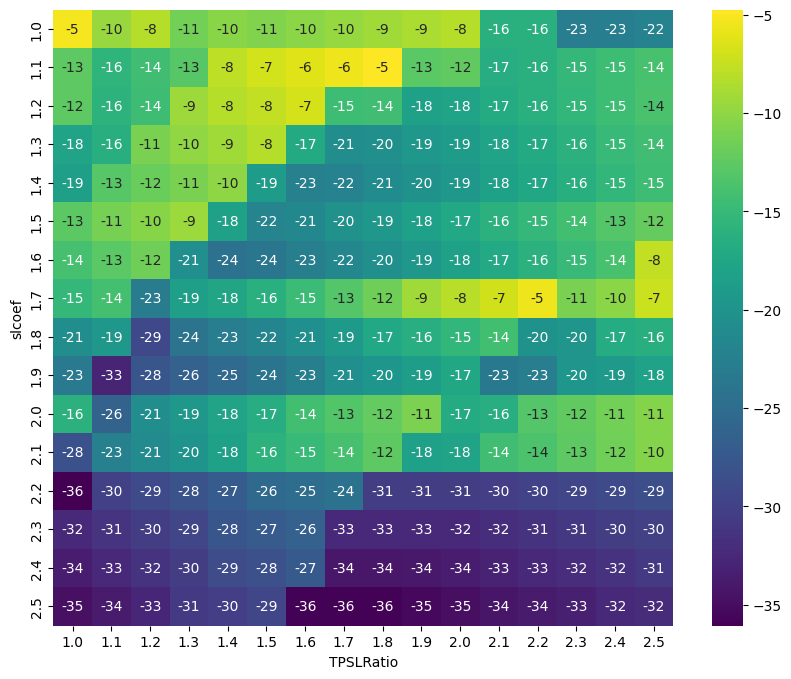

In [62]:
# Convert multiindex series to dataframe
heatmap_df = heatmap.unstack()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df, annot=True, cmap='viridis', fmt='.0f')
plt.show()